# 第五階段:升級空間指標 —— Voronoi 控制區

**最終目標**:做一個「傳球空間分析」工具,給教練或球探使用。

**本階段只做一件事**:用 **Voronoi 控制區**回答一個更完整的問題 —— 「整片球場,哪一塊分別被誰控制?進攻還是防守?」

前面第三、四階段用的 separation(最近防守者距離)只看「每個接球員頭上有沒有人盯」。但它看不到整片場地的空間歸屬:接球員跑向的區域是不是其實有別人補位?哪裡才是真正可傳的通道?**Voronoi 把視角從「單點距離」升級成「整片場地」。**

---

### 什麼是 Voronoi 控制區?(白話版)

把球場上每一個小點,**分配給離它最近的那位球員**。於是整片場地被切成一塊塊,每塊「屬於」某位球員;把同隊球員的塊加起來,就是**這一隊控制的面積**。

> 直覺:一個點離你最近,代表你最有機會先到那裡。所以「你控制的區域」= 全場裡「你是最近球員」的那些地方。這是運動分析常用的空間模型。

### 做法:用網格近似(簡單又穩健)

我們不直接畫 Voronoi 多邊形,而是**把球場鋪成細網格**,對每個網格點問「最近的球員是誰、屬於哪一隊」,再數格子算面積。這樣:
- 面積好算(數格子 × 每格面積)。
- 不用處理多邊形邊界的數學細節,邊界(球場範圍)也天然受限。

## 步驟 0:載入工具與設定路徑

- **輸入**:無
- **輸出**:`pandas`、`numpy`、`matplotlib`、`scipy.spatial.cKDTree`、路徑設定
- **目的**:準備工具。`cKDTree` 是 scipy 的「最近鄰查詢」工具,能很快回答「每個網格點最近的球員是誰」。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.spatial import cKDTree

# 中文字型(macOS 內建),避免圖上中文顯示成方框
plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

sys.path.append(str(Path.cwd().parent))
from config import DATA_DIR, SAMPLE_GAME_ID

SAMPLE_PLAY_ID = 137  # 延續前面階段的同一個 play
print("gameId:", SAMPLE_GAME_ID, "/ playId:", SAMPLE_PLAY_ID)

gameId: 2021090900 / playId: 137


## 步驟 1:重建 snap → pass 片段(含球隊歸屬)

- **輸入**:`tracking`、`plays`
- **輸出**:`dropback`(片段)、`off_team` / `def_team`(進攻 / 防守隊代碼)
- **目的**:讓本筆記本可獨立執行。這一階段**不需要** pff 角色(Voronoi 看的是「所有球員」的位置,不分跑路線或防守),只需要知道每位球員屬於哪一隊。

> tracking 的 `team` 欄位就是球隊代碼。配合 `plays` 的 `possessionTeam`(進攻)和 `defensiveTeam`(防守),就能把球員分成攻 / 守兩邊。

In [2]:
plays = pd.read_csv(DATA_DIR / "plays.csv")
tracking = pd.read_csv(DATA_DIR / "tracking" / f"tracking_{SAMPLE_GAME_ID}.csv")

this_play = plays[(plays["gameId"] == SAMPLE_GAME_ID) & (plays["playId"] == SAMPLE_PLAY_ID)]
off_team = this_play["possessionTeam"].iloc[0]
def_team = this_play["defensiveTeam"].iloc[0]

play_track = tracking[
    (tracking["gameId"] == SAMPLE_GAME_ID) & (tracking["playId"] == SAMPLE_PLAY_ID)
].copy()
snap_frame = play_track.loc[play_track["event"] == "ball_snap", "frameId"].iloc[0]
pass_frame = play_track.loc[play_track["event"] == "pass_forward", "frameId"].iloc[0]

dropback = play_track[
    (play_track["frameId"] >= snap_frame) & (play_track["frameId"] <= pass_frame)
].copy()

print("進攻隊:", off_team, "/ 防守隊:", def_team)
print("snap frame:", snap_frame, "/ pass frame:", pass_frame)
print("片段 frame 數:", dropback["frameId"].nunique())

進攻隊: DAL / 防守隊: TB
snap frame: 7 / pass frame: 32
片段 frame 數: 26


## 步驟 2:鋪一張球場網格

- **輸入**:球場尺寸(x: 0–120 碼、y: 0–53.3 碼)
- **輸出**:`grid`(所有網格點座標)、`cell_area`(每格面積)
- **目的**:把球場切成 0.5 碼 × 0.5 碼的小格,每格用中心點代表。之後對每格問「最近球員是誰」。

> 格子越小越精細、但越慢。0.5 碼在精度與速度之間剛好,足以算面積佔比。

In [3]:
FIELD_X, FIELD_Y = 120.0, 53.3   # 球場長 × 寬(碼)
STEP = 0.5                        # 網格邊長(碼)

gx = np.arange(0, FIELD_X, STEP) + STEP / 2   # 每格中心
gy = np.arange(0, FIELD_Y, STEP) + STEP / 2
GX, GY = np.meshgrid(gx, gy)
grid = np.column_stack([GX.ravel(), GY.ravel()])
cell_area = STEP * STEP

print("網格形狀 (列, 欄):", GX.shape)
print("網格點總數:", len(grid))
print("每格面積:", cell_area, "平方碼")
print("網格涵蓋總面積:", round(len(grid) * cell_area, 1),
      "平方碼(球場實際約", round(FIELD_X * FIELD_Y, 1), ")")

網格形狀 (列, 欄): (107, 240)
網格點總數: 25680
每格面積: 0.25 平方碼
網格涵蓋總面積: 6420.0 平方碼(球場實際約 6396.0 )


## 步驟 3:核心計算 —— 單一 frame 的控制面積

- **輸入**:某個 frame 的 22 位球員座標 + 隊別
- **輸出**:這一格裡進攻 / 防守各控制多少面積、佔比
- **目的**:把 Voronoi 控制區包成一個函式,先在 **snap 當下**算一次。

**做法**:用 `cKDTree` 幫每個網格點找最近的球員 → 查那位球員屬於哪一隊 → 數格子算面積。

In [4]:
def control_at_frame(frame_id):
    """回傳 (owner_team 陣列, 進攻面積, 防守面積)。owner_team 可畫熱力圖用。"""
    fg = dropback[(dropback["frameId"] == frame_id) & dropback["nflId"].notna()]  # 只要球員,排除球
    pts = fg[["x", "y"]].to_numpy()
    teams = fg["team"].to_numpy()

    tree = cKDTree(pts)
    _, idx = tree.query(grid)          # 每個網格點 → 最近球員的索引
    owner_team = teams[idx]            # 那位球員的隊別

    off_area = (owner_team == off_team).sum() * cell_area
    def_area = (owner_team == def_team).sum() * cell_area
    return owner_team, off_area, def_area


owner_snap, off_a, def_a = control_at_frame(snap_frame)
total = off_a + def_a
print("=== 發球(snap)當下的場地控制 ===")
print(f"進攻 {off_team}:{off_a:.0f} 平方碼 → {off_a/total*100:.1f}%")
print(f"防守 {def_team}:{def_a:.0f} 平方碼 → {def_a/total*100:.1f}%")

=== 發球(snap)當下的場地控制 ===
進攻 DAL:709 平方碼 → 11.0%
防守 TB:5711 平方碼 → 89.0%


## 步驟 4:畫出 snap 當下的控制區熱力圖

- **輸入**:`owner_snap`(每個網格點屬於哪一隊)
- **輸出**:一張球場熱力圖
- **目的**:把「哪塊場地屬於誰」直接畫出來。藍=進攻控制、紅=防守控制,再疊上球員位置。

> 這張圖讓抽象的「控制面積 %」變成一眼看懂的空間地圖。

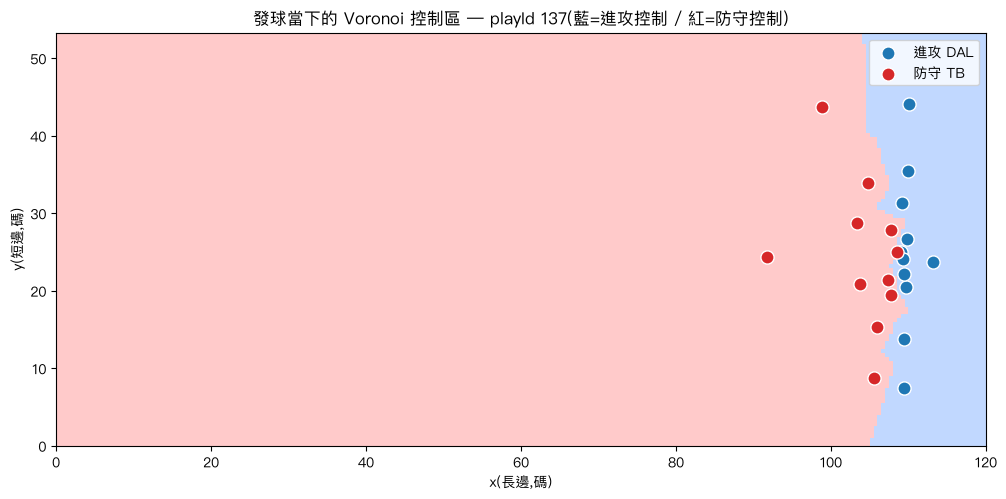

In [5]:
# 把 owner_team(字串)轉成 0/1,好畫色塊:0=進攻、1=防守
owner_grid = (owner_snap == def_team).astype(int).reshape(GX.shape)
cmap = ListedColormap(["#a6c8ff", "#ffb3b3"])  # 淡藍=進攻, 淡紅=防守

snap_players = dropback[(dropback["frameId"] == snap_frame) & dropback["nflId"].notna()]
off_p = snap_players[snap_players["team"] == off_team]
def_p = snap_players[snap_players["team"] == def_team]

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(owner_grid, origin="lower", extent=[0, FIELD_X, 0, FIELD_Y],
          cmap=cmap, alpha=0.7, aspect="equal")
ax.scatter(off_p["x"], off_p["y"], c="tab:blue", s=90, edgecolor="white",
           label=f"進攻 {off_team}", zorder=3)
ax.scatter(def_p["x"], def_p["y"], c="tab:red", s=90, edgecolor="white",
           label=f"防守 {def_team}", zorder=3)
ax.set_xlim(0, FIELD_X)
ax.set_ylim(0, FIELD_Y)
ax.set_xlabel("x(長邊,碼)")
ax.set_ylabel("y(短邊,碼)")
ax.set_title(f"發球當下的 Voronoi 控制區 — playId {SAMPLE_PLAY_ID}(藍=進攻控制 / 紅=防守控制)")
ax.legend(loc="upper right")
plt.show()

## 步驟 5:控制面積在 snap → pass 之間怎麼變化

- **輸入**:片段裡的每個 frame
- **輸出**:`control_ts`(每個 frame 的進攻 / 防守控制佔比)+ 折線圖
- **目的**:play 展開的這幾秒,進攻方有沒有「打開空間」(控制佔比上升)?這比單一時刻更能看出空間的動態。

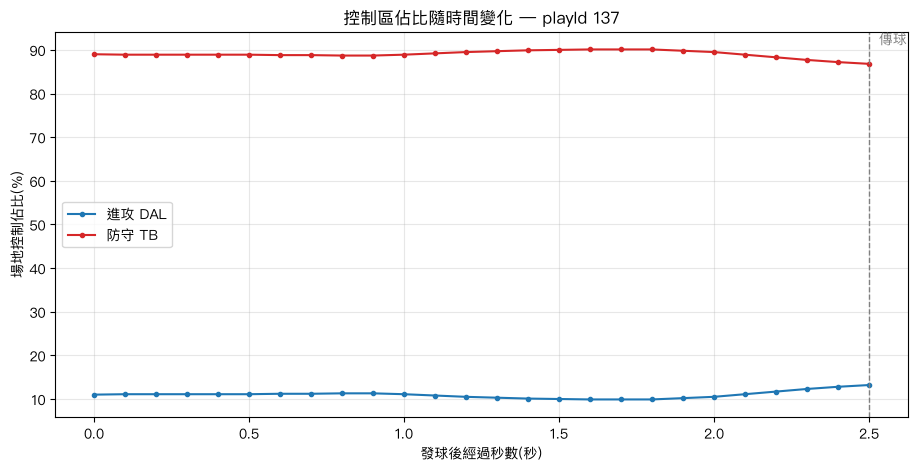

 seconds_since_snap  offense_pct  defense_pct
                0.0         11.0         89.0
                0.1         11.1         88.9
                0.2         11.1         88.9
                0.3         11.1         88.9
                0.4         11.1         88.9
                0.5         11.1         88.9
                0.6         11.2         88.8
                0.7         11.2         88.8
                0.8         11.3         88.7
                0.9         11.3         88.7
                1.0         11.1         88.9
                1.1         10.8         89.2
                1.2         10.5         89.5
                1.3         10.3         89.7
                1.4         10.1         89.9
                1.5         10.0         90.0
                1.6          9.9         90.1
                1.7          9.9         90.1
                1.8          9.9         90.1
                1.9         10.2         89.8
                2.0         10.5  

In [6]:
ts_rows = []
for frame_id in sorted(dropback["frameId"].unique()):
    _, off_a, def_a = control_at_frame(frame_id)
    total = off_a + def_a
    ts_rows.append({
        "seconds_since_snap": round((frame_id - snap_frame) * 0.1, 1),
        "offense_pct": round(off_a / total * 100, 1),
        "defense_pct": round(def_a / total * 100, 1),
    })
control_ts = pd.DataFrame(ts_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(control_ts["seconds_since_snap"], control_ts["offense_pct"],
        marker="o", markersize=3, color="tab:blue", label=f"進攻 {off_team}")
ax.plot(control_ts["seconds_since_snap"], control_ts["defense_pct"],
        marker="o", markersize=3, color="tab:red", label=f"防守 {def_team}")
pass_sec = round((pass_frame - snap_frame) * 0.1, 1)
ax.axvline(pass_sec, color="gray", linestyle="--", linewidth=1)
ax.text(pass_sec, ax.get_ylim()[1], "  傳球", va="top", color="gray")
ax.set_xlabel("發球後經過秒數(秒)")
ax.set_ylabel("場地控制佔比(%)")
ax.set_title(f"控制區佔比隨時間變化 — playId {SAMPLE_PLAY_ID}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(control_ts.to_string(index=False))

## 本階段完成了什麼

- 從「最近防守者距離(separation)」升級到「整片場地的 **Voronoi 控制區**」。
- 用網格 + `cKDTree` 近似:把球場鋪成細格,每格分配給最近球員所屬的隊,數格子算面積。
- 算出 snap 當下進攻 / 防守各控制多少場地,並畫成**控制區熱力圖**(藍=進攻 / 紅=防守)。
- 追蹤控制佔比在 snap → pass 之間的變化,看出空間的動態消長。

**為什麼這比 separation 更完整?** separation 只回答「某個接球員頭上有沒有人」;Voronoi 回答「整片場地分別屬於誰」,能看到補位、通道、包夾等 separation 看不到的空間結構。

**下一階段(等你確認理解後再開始)**:
1. **把控制區批次化到整場 / 多場**(沿用第四階段的批次框架,統計每個 play 傳球瞬間的控制佔比)。
2. **聚焦「傳球路徑上的空間」**:不只看全場控制,而是計算「從 QB 到各接球員的傳球通道」上是否被防守控制,更貼近傳球決策。